In [1]:
complexity_idx = int(input("INPUT 'visualization_target for complexity RUN_ID'(e.g., 20000): "))

print(f'Figure will be drawn based on the run_id_{complexity_idx} dataset')

Figure will be drawn based on the run_id_20000 dataset


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cyclomatic_complexity import calculate_cyclomatic_complexity
from lib.utils.file_io import read_complexity_jsonl

import lib.stats.chowtest as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.code_complexity.tools.Result_Prep import Result_Prep as Result_Prep_C
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.figure_setting as figure_setting
from lib.visualization.plot_generator import PlotGen
mpl.rcParams.update(figure_setting.fig_setting)
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

import statsmodels.formula.api as smf
from scipy import stats

from scipy.stats import linregress, ttest_1samp
from statsmodels.stats.multitest import multipletests

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from lib.stats.its import ITS
from lib.stats.ls import LS
from adjustText import adjust_text  # pip install adjustText




In [3]:
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'
MIN_WEEK     = -104
MAX_WEEK     = +160
MIN_PRE  = 50
MIN_POST = 50

### Load data
- code complexity
- question volume


In [4]:
tot_viz_df = pd.DataFrame()
for idx, lang in enumerate(list({lang: set_ for lang, set_ in CONSTANTS.LANG_INFO.items() if set_[1] is not None}.keys())):
    print(f'[visualizing....] start visualizing {lang} language')
    rp_c = Result_Prep_C(int(complexity_idx)+idx)
    viz_df = rp_c.data_prep_for_all(lang)
    tot_viz_df = pd.concat([tot_viz_df, viz_df], ignore_index=True)

df = rp_c.data_prep_for_its(tot_viz_df)

[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:12<00:00,  5.04it/s]


[visualizing....] start visualizing javascript language


100%|██████████| 65/65 [00:07<00:00,  8.78it/s]


[visualizing....] start visualizing java language


...

100%|██████████| 65/65 [00:00<00:00, 1017.37it/s]


[visualizing....] start visualizing fortran language


100%|██████████| 65/65 [00:00<00:00, 1271.58it/s]


[visualizing....] start visualizing solidity language


100%|██████████| 65/65 [00:00<00:00, 782.65it/s]


In [5]:
panel = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] Aggreagate data for {lang} language')
    tmp = load_df(f'/mnt/hdd/mghan/so_data_availability/result/tag/run_id_{100+idx}/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp['language'] = lang
    panel = pd.concat([panel, tmp], axis = 0)

panel['rel_week'] = (pd.to_datetime(panel['cdate']) - datetime(2022, 11, 30)).dt.days //7
panel = panel[panel['rel_week']<0].groupby(['language'])['pct'].sum().reset_index().rename(columns = {'pct' : 'post_count'})
panel['log_post_count'] = np.log(panel['post_count']) 

[Start....] Aggreagate data for python language


100%|██████████| 153/153 [00:06<00:00, 25.16it/s]


[Start....] Aggreagate data for javascript language


100%|██████████| 108/108 [00:04<00:00, 24.78it/s]


[Start....] Aggreagate data for java language


...

100%|██████████| 1/1 [00:00<00:00, 78.33it/s]


[Start....] Aggreagate data for f# language


100%|██████████| 1/1 [00:00<00:00, 126.27it/s]


[Start....] Aggreagate data for solidity language


100%|██████████| 2/2 [00:00<00:00, 62.74it/s]


### Select languages that have proper volume to be analyzed

In [6]:
df['t']      = df['rel_week']
df['post']   = (df['rel_week'] >= 0).astype(int)
df['post_t'] = df['post'] * df['rel_week']


# ★ pre/post 데이터 충분한 언어만 선별
cov = df.groupby('language').agg(
    n_pre  = ('t', lambda s: (s < 0).sum()),
    n_post = ('t', lambda s: (s >= 0).sum()),
).reset_index()
keep_langs = cov[(cov['n_pre'] >= MIN_PRE) &
                 (cov['n_post'] >= MIN_POST)]['language'].tolist()

dropped = sorted(set(df['language'].unique()) - set(keep_langs))
df = df[df['language'].isin(keep_langs)].copy()

print(f"포함 언어 ({len(keep_langs)}): {sorted(keep_langs)}")
print(f"제외 언어 ({len(dropped)}): {dropped}")
print(f"기준: pre>={MIN_PRE}, post>={MIN_POST}주")
print(f"분석 데이터: {len(df):,}개 행")
 
print(f"n = {len(df):,}, 언어 = {df['language'].nunique()}")
print(f"기간: {df['rel_week'].min()} ~ {df['rel_week'].max()}주")
 


포함 언어 (13): ['c', 'c#', 'c++', 'go', 'java', 'javascript', 'kotlin', 'php', 'python', 'r', 'rust', 'swift', 'typescript']
제외 언어 (6): ['fortran', 'lua', 'objective-c', 'ruby', 'scala', 'solidity']
기준: pre>=50, post>=50주
분석 데이터: 3,099개 행
n = 3,099, 언어 = 13
기간: -104 ~ 155주


## 전체 언어에 대한  ITS수행

In [7]:
tot_its_df  =  df.sort_values(['language', 't']).reset_index(drop=True).copy()
tot_its     = ITS(TARGET, tot_its_df)

tot_its.set_tot_its_model()
t_obs = tot_its.get_tot_model_coef()
eff_smooth = tot_its.get_tot_model_coef_se(np.arange(MIN_WEEK, MAX_WEEK+1, 1))
p_slope = tot_its.model.pvalues['post_t']

## 언어 개별 ITS수행

In [8]:
indi_its_df = df.sort_values(['language', 't']).reset_index(drop=True).copy()
indi_its_results = []

for lang in sorted(indi_its_df['language'].unique()):
    
    sub         = indi_its_df[indi_its_df['language'] == lang].sort_values('t').copy()
    sub_its     = ITS(TARGET, sub)
    sub_its.set_indi_its_model()
    indi_its_results.append(sub_its.get_indi_its_result(lang))

its_lang_df = pd.DataFrame(indi_its_results)
its_lang_df = pd.merge(its_lang_df, panel, on = 'language')
its_lang_df['post_count'] = its_lang_df['post_count'].astype(int)
its_lang_df = its_lang_df.sort_values('log_post_count', ascending=True).reset_index(drop=True)
sorted_s = its_lang_df.sort_values(by = ['log_post_count']).reset_index(drop=True)

In [9]:
x   = its_lang_df['log_post_count']
y   = its_lang_df['pct']
xx  = np.linspace(its_lang_df['log_post_count'].min(), its_lang_df['log_post_count'].max(), 100)
weight = 1 / (its_lang_df['se_yr'] ** 2)

ols = LS(x, y)
ols.conduct_ols()
ols_result = ols.get_ls_result()
ols_prediction = ols.get_prediction(xx)

wls = LS(x, y)
wls.conduct_wls(weight)
wls_result = wls.get_ls_result()
wls_prediction = wls.get_prediction(xx)

OLS: slope = 0.81
$R^2$ = 0.26, n.s.


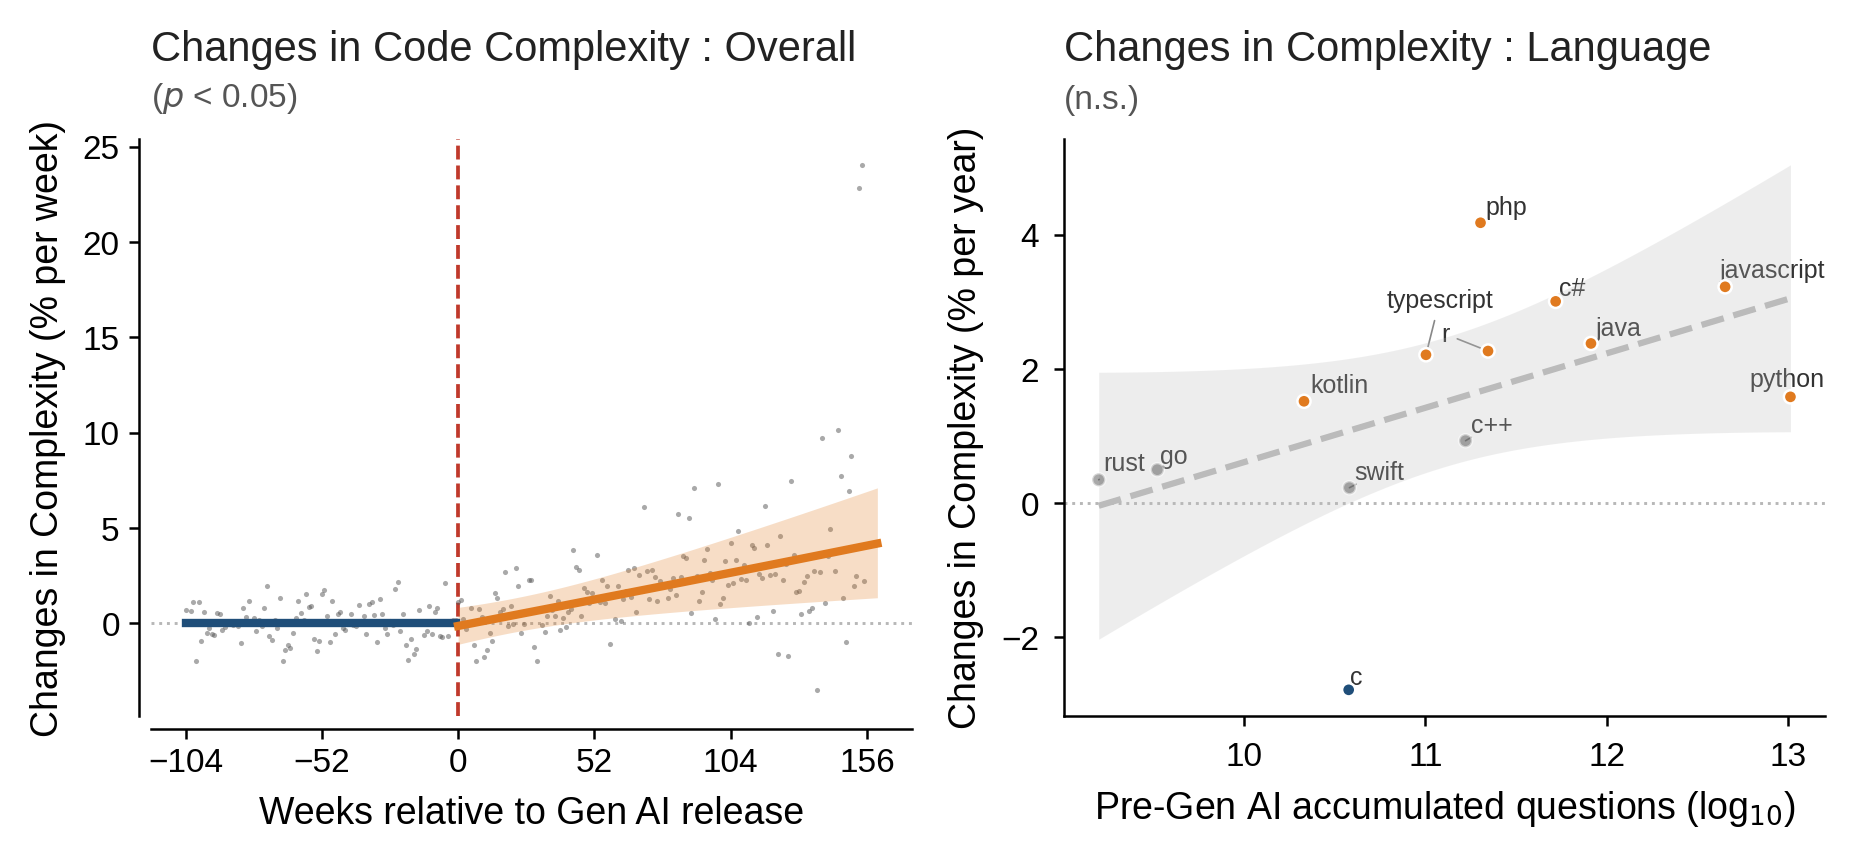

In [10]:

fig = plt.figure(figsize=(7.2, 2.5), dpi=300)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# a: 3패널 (각 2칸씩)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])


plotgen = PlotGen()

ax_a.axhline(0, color='#999', lw=0.7, ls=':', alpha=0.7, zorder=0)

x = t_obs['t']
y = t_obs['eff']

plotgen.draw_scatter_plot(ax_a, x, y)
plotgen.draw_line_plot(          ax_a,    eff_smooth.loc[eff_smooth['t'] <  0, 't'], \
                                        eff_smooth.loc[eff_smooth['t'] <  0, 'effect_pct'], \
                                        color=figure_setting.PALETTE['primary'])
plotgen.draw_line_plot(          ax_a,    eff_smooth.loc[eff_smooth['t'] >=  0, 't'], \
                                        eff_smooth.loc[eff_smooth['t'] >=  0, 'effect_pct'], \
                                        color=figure_setting.PALETTE['accent'])

plotgen.fill_confidence_interval(ax_a,    eff_smooth.loc[eff_smooth['t'] >= 0, 't'],\
                                        eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_low_pct'], \
                                        eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_high_pct'], \
                                        color=figure_setting.PALETTE['accent'])
plotgen.draw_vertical_line(ax_a, x)
plotgen.set_spines(ax_a)
plotgen.set_xticks(ax_a, np.arange(-104, 157, 52))
plotgen.set_title_two_lines(ax_a, title_text='Changes in Code Complexity : Overall', p_value= float(p_slope))

ax_a.set_xlabel('Weeks relative to Gen AI release')
ax_a.set_ylabel('Changes in Complexity (% per week)')


# ===================================================================

ax_b.axhline(0, color='#999', lw=0.7, ls=':', alpha=0.7, zorder=0)

plotgen.fill_confidence_interval(ax_b, xx, ols_prediction['ci_low'], ols_prediction['ci_high'], 
                                 color=figure_setting.PALETTE['point'])



ax_b.plot(xx, ols_prediction['yy'], color=figure_setting.PALETTE['point'], ls='--', lw=1.5, zorder=2)

ax_b.scatter(its_lang_df['log_post_count'], its_lang_df['pct'],
             s=10, facecolor=its_lang_df['color_slope'],
             edgecolor='white', linewidth=0.6, zorder=5,
             alpha=its_lang_df['alpha'])

# for _, row in its_lang_df.iterrows():
#     ax_b.annotate(row['language'], (row['log_post_count'], row['pct']),
#                   textcoords="offset points", xytext=(5, 4), fontsize=8, zorder=4)


texts = []
for _, row in its_lang_df.iterrows():
    weight = 'normal'
    color  = '#333'
    texts.append(ax_b.text(row['log_post_count'], row['pct'], row['language'],
                         fontsize=6, color=color, weight=weight))

adjust_text(texts, ax=ax_b,
            expand=(1.2, 1.4),
            arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))

    
sig_str = '$p$ < 0.001' if ols_result['p_val'] < 0.001 else ( 'p < 0.05' if ols_result['p_val']< 0.05 else 'n.s.')
# ax_b.text(0.97, 0.15,
#           f"OLS: slope = {ols_result['slope_fit']:.2f}\n$R^2$ = {ols_result['r_squared']:.2f}, {sig_str}",
#           transform=ax_b.transAxes, ha='right', va='bottom', fontsize=8)

print(f"OLS: slope = {ols_result['slope_fit']:.2f}\n$R^2$ = {ols_result['r_squared']:.2f}, {sig_str}")



ax_b.set_xlabel('Pre-Gen AI accumulated questions (log$_{10}$)')
ax_b.set_ylabel('Changes in Complexity (% per year)')
for s in ['top', 'right']:
    ax_b.spines[s].set_visible(False)
plotgen.set_title_two_lines(ax_b, title_text='Changes in Complexity : Language', p_value = ols_result['p_val'])
plt.savefig('./fig/Fig4_AB_1.pdf', bbox_inches='tight', dpi=300)


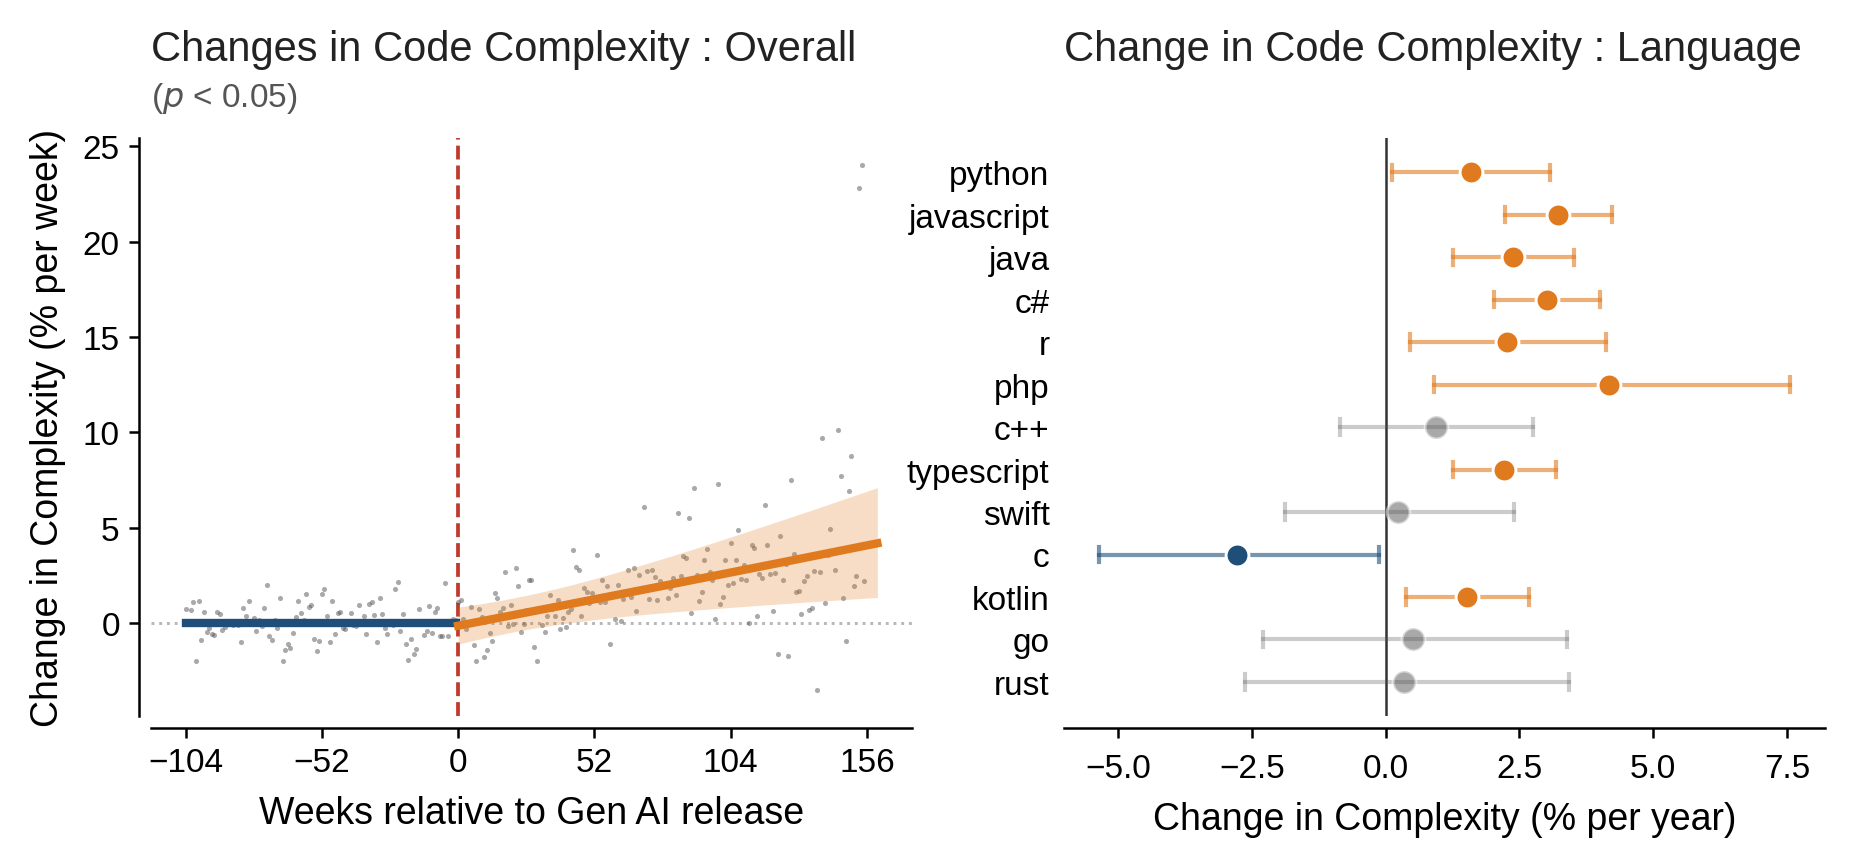

In [11]:

fig = plt.figure(figsize=(7.2, 2.5), dpi=300)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# a: 3패널 (각 2칸씩)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])


plotgen = PlotGen()

ax_a.axhline(0, color='#999', lw=0.7, ls=':', alpha=0.7, zorder=0)

x = t_obs['t']
y = t_obs['eff']

plotgen.draw_scatter_plot(ax_a, x, y)
plotgen.draw_line_plot(          ax_a,    eff_smooth.loc[eff_smooth['t'] <  0, 't'], \
                                        eff_smooth.loc[eff_smooth['t'] <  0, 'effect_pct'], \
                                        color=figure_setting.PALETTE['primary'])
plotgen.draw_line_plot(          ax_a,    eff_smooth.loc[eff_smooth['t'] >=  0, 't'], \
                                        eff_smooth.loc[eff_smooth['t'] >=  0, 'effect_pct'], \
                                        color=figure_setting.PALETTE['accent'])

plotgen.fill_confidence_interval(ax_a,    eff_smooth.loc[eff_smooth['t'] >= 0, 't'],\
                                        eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_low_pct'], \
                                        eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_high_pct'], \
                                        color=figure_setting.PALETTE['accent'])
plotgen.draw_vertical_line(ax_a, x)
plotgen.set_spines(ax_a)
plotgen.set_xticks(ax_a, np.arange(-104, 157, 52))
plotgen.set_title_two_lines(ax_a, title_text='Changes in Code Complexity : Overall', p_value= float(p_slope))

ax_a.set_xlabel('Weeks relative to Gen AI release')
ax_a.set_ylabel('Change in Complexity (% per week)')


# ===================================================================



ax_b.axvline(0, color='#333', lw=0.6, zorder=1)
# ax.axvline(pool_slope_yr, color=figure_setting.PALETTE['event'], lw=0.9, ls='--', zorder=1)

for i, row in sorted_s.iterrows():
    # 95% CI 막대
    ax_b.plot([row['ci_low'], row['ci_high']], [i, i],
            color=row['color_slope'], lw=1, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['ci_low'], row['ci_high']]:
        ax_b.plot([xe, xe], [i-0.18, i+0.18],
                color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    # 점추정
    ax_b.scatter(row['pct'], i, s=30,
               facecolor=row['color_slope'], edgecolor='white',
               linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_b.set_yticks(np.arange(len(sorted_s)))
ax_b.set_yticklabels([f"{r['language']}"
                    for _, r in sorted_s.iterrows()])

for s in ['top', 'right']: ax_b.spines[s].set_visible(False)
ax_b.spines['left'].set_visible(False)
ax_b.spines['bottom'].set_position(('outward', 3))
ax_b.tick_params(axis='y', length=0)
ax_b.set_xlabel('Change in Complexity (% per year)')
plotgen.set_title_two_lines(ax_b, title_text='Change in Code Complexity : Language')

plt.savefig('./fig/Fig4_AB_2.pdf', bbox_inches='tight', dpi=300)
